In [3]:
import pandas as pd

In [5]:
df = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding='latin-1', header=None)

In [6]:
df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
df = df[['sentiment', 'text']]
df['sentiment'] = df['sentiment'].replace(4, 1)

df.head(10)

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."
5,0,@Kwesidei not the whole crew
6,0,Need a hug
7,0,@LOLTrish hey long time no see! Yes.. Rains a...
8,0,@Tatiana_K nope they didn't have it
9,0,@twittera que me muera ?


In [19]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower().split()
    text = [word for word in text if word not in stop_words]
    return " ".join(text)

df['clean_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


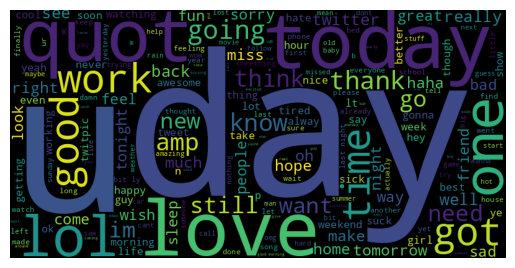

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400).generate(all_words)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=500)
tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(X, maxlen=50)

In [22]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(df['sentiment'])

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense

model = Sequential()

model.add(Embedding(input_dim=500, output_dim=120, input_shape=(X.shape[1],)))
model.add(SpatialDropout1D(0.4))
model.add(LSTM(176, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(2, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.build(input_shape=(None, X.shape[1]))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 120)        │        60,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 50, 120)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 176)            │       209,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,442 (1.03 MB)

 Trainable params: 269,442 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
import pandas as pd

df = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding='latin-1', header=None)
df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
df = df[['sentiment', 'text']]
df['sentiment'] = df['sentiment'].replace(4, 1)

# take a smaller balanced sample
df_neg = df[df['sentiment'] == 0].sample(10000, random_state=42)
df_pos = df[df['sentiment'] == 1].sample(10000, random_state=42)

df = pd.concat([df_neg, df_pos]).sample(frac=1, random_state=42).reset_index(drop=True)

df.head(10)

,sentiment,text
0,1,@DawnRichard THANKS LUV...KEEP THE GRIND GOING...
1,0,I feel like watching The Life Aquatic. But I d...
2,0,So aparentally early this morning Erol died of...
3,0,"Chopchop, get dressed! Getting ready for work"
4,1,@misshaleymae You know it baby ! x
5,1,Morning Tweoples!! Hope everyone enjoys their ...
6,1,@vickyjones91 yeah i thought like tht for Jona...
7,0,I suppose I will do more vacation research alo...
8,1,@dieverdog I got the same two hits. the phone ...
9,0,"hanging out with the sis today. It's rainy, th..."


In [26]:
model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 72s 137ms/step - accuracy: 0.6596 - loss: 0.6056
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 77s 127ms/step - accuracy: 0.7041 - loss: 0.5568
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 125ms/step - accuracy: 0.7109 - loss: 0.5486
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 128ms/step - accuracy: 0.7191 - loss: 0.5409
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 122ms/step - accuracy: 0.7213 - loss: 0.5329


In [27]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

print(classification_report(y_test_labels, y_pred))

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step
              precision    recall  f1-score   support

           0       0.72      0.70      0.71      2055
           1       0.69      0.72      0.70      1945

    accuracy                           0.71      4000
   macro avg       0.71      0.71      0.71      4000
weighted avg       0.71      0.71      0.71      4000



In [29]:
def predict_review():
    review = input("Enter a review: ")
    cleaned = clean_text(review)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=50)
    pred = model.predict(padded)
    result = np.argmax(pred)
    print("Predicted Sentiment:", "Positive" if result == 1 else "Negative")

predict_review()

Enter a review: This is the worst thing I have ever used
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Sentiment: Negative
